<a href="https://colab.research.google.com/github/baekka1/Crop-Yield-Prediction/blob/main/Notebooks/Week3_Tasks/Updated_Week_3_Classical_Regression_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVR

In [ ]:
def summarize_array(X, prefix):
    """Compute summary stats for one NumPy array and add a feature prefix."""
    return pd.DataFrame({
        f'{prefix}_mean': np.nanmean(X, axis=1),
        f'{prefix}_std': np.nanstd(X, axis=1),
        f'{prefix}_min': np.nanmin(X, axis=1),
        f'{prefix}_max': np.nanmax(X, axis=1),
        f'{prefix}_q25': np.nanpercentile(X, 25, axis=1),
        f'{prefix}_q50': np.nanpercentile(X, 50, axis=1),
        f'{prefix}_q75': np.nanpercentile(X, 75, axis=1),
        f'{prefix}_skew': [skew(row, nan_policy='omit') for row in X],
        f'{prefix}_kurt': [kurtosis(row, nan_policy='omit') for row in X]
    })

file_names = [
    '/content/drive/MyDrive/Data Science Capstone/X_pr_1980_2018_rawyield',
    '/content/drive/MyDrive/Data Science Capstone/X_rmax_1980_2018_rawyield',
    '/content/drive/MyDrive/Data Science Capstone/X_rmin_1980_2018_rawyield',
    '/content/drive/MyDrive/Data Science Capstone/X_sph_1980_2018_rawyield',
    '/content/drive/MyDrive/Data Science Capstone/X_srad_1980_2018_rawyield',
    '/content/drive/MyDrive/Data Science Capstone/X_th_1980_2018_rawyield',
    '/content/drive/MyDrive/Data Science Capstone/X_tmmn_1980_2018_rawyield',
    '/content/drive/MyDrive/Data Science Capstone/X_tmmx_1980_2018_rawyield',
    '/content/drive/MyDrive/Data Science Capstone/X_vpd_1980_2018_rawyield',
    '/content/drive/MyDrive/Data Science Capstone/X_vs_1980_2018_rawyield',
]

prefixes = ['pr', 'rmin', 'rmax', 'sph', 'srad', 'th', 'tmmn', 'tmmx', 'vpd', 'vs']

summary_frames = []

for fname, prefix in zip(file_names, prefixes):
    print(f"Processing {prefix}...")
    X = np.load(fname, allow_pickle=True)
    summary_frames.append(summarize_array(X, prefix))
    print(f"✅ Done with {prefix}")

Processing pr...
✅ Done with pr
Processing rmin...
✅ Done with rmin
Processing rmax...
✅ Done with rmax
Processing sph...
✅ Done with sph
Processing srad...
✅ Done with srad
Processing th...
✅ Done with th
Processing tmmn...
✅ Done with tmmn
Processing tmmx...
✅ Done with tmmx
Processing vpd...
✅ Done with vpd
Processing vs...
✅ Done with vs


In [ ]:
combined_df = pd.concat(summary_frames, axis=1)

print(combined_df.shape)
combined_df.head()


(45338, 90)


,pr_mean,pr_std,pr_min,pr_max,pr_q25,pr_q50,pr_q75,pr_skew,pr_kurt,rmin_mean,...,vpd_kurt,vs_mean,vs_std,vs_min,vs_max,vs_q25,vs_q50,vs_q75,vs_skew,vs_kurt
0,2.150448,4.413489,0.0,21.282090,0.0,0.0,1.711567,2.621908,6.717262,88.534865,...,-0.161947,4.169133,1.434465,1.029104,7.964179,3.073321,3.969403,5.230970,0.361223,-0.440749
1,2.342725,5.499536,0.0,36.751111,0.0,0.0,1.874722,3.473833,13.583436,85.865079,...,-0.229766,3.564974,1.157033,1.023333,6.747778,2.670556,3.421111,4.299722,0.381027,-0.331431
2,2.067676,5.973680,0.0,54.501980,0.0,0.0,0.788119,5.188647,33.930697,91.763880,...,-0.380704,3.560391,1.283522,1.418812,7.563366,2.460891,3.368812,4.320792,0.663900,-0.025711
3,2.714061,7.396576,0.0,59.416364,0.0,0.0,1.476818,5.025744,31.696129,88.569844,...,-0.689925,3.964970,1.417670,1.163636,8.394545,2.895000,3.758182,4.767273,0.708576,0.003399
4,2.435780,7.926519,0.0,69.161765,0.0,0.0,0.915441,5.566136,36.146785,89.555033,...,-0.792277,3.494477,1.267430,1.377451,7.835294,2.517892,3.332353,4.236520,0.643525,-0.078172


In [ ]:
labels = pd.read_csv('/content/drive/MyDrive/Data Science Capstone/label_1980_2018_rawyield.csv')
print(labels.shape)
labels.head()

(45338, 5)


,Unnamed: 0,index,id2,year,yield
0,0,1,112,1980,27.0
1,1,2,113,1980,28.0
2,2,3,119,1980,29.0
3,3,4,120,1980,28.0
4,4,5,124,1980,24.0


In [ ]:
final_df = pd.concat([labels, combined_df], axis=1)
print(final_df.shape)
final_df.head()

(45338, 95)


,Unnamed: 0,index,id2,year,yield,pr_mean,pr_std,pr_min,pr_max,pr_q25,...,vpd_kurt,vs_mean,vs_std,vs_min,vs_max,vs_q25,vs_q50,vs_q75,vs_skew,vs_kurt
0,0,1,112,1980,27.0,2.150448,4.413489,0.0,21.282090,0.0,...,-0.161947,4.169133,1.434465,1.029104,7.964179,3.073321,3.969403,5.230970,0.361223,-0.440749
1,1,2,113,1980,28.0,2.342725,5.499536,0.0,36.751111,0.0,...,-0.229766,3.564974,1.157033,1.023333,6.747778,2.670556,3.421111,4.299722,0.381027,-0.331431
2,2,3,119,1980,29.0,2.067676,5.973680,0.0,54.501980,0.0,...,-0.380704,3.560391,1.283522,1.418812,7.563366,2.460891,3.368812,4.320792,0.663900,-0.025711
3,3,4,120,1980,28.0,2.714061,7.396576,0.0,59.416364,0.0,...,-0.689925,3.964970,1.417670,1.163636,8.394545,2.895000,3.758182,4.767273,0.708576,0.003399
4,4,5,124,1980,24.0,2.435780,7.926519,0.0,69.161765,0.0,...,-0.792277,3.494477,1.267430,1.377451,7.835294,2.517892,3.332353,4.236520,0.643525,-0.078172


In [ ]:
df = final_df.sort_values(["id2", "year"])
df["prev_yield"] = df.groupby("id2")["yield"].shift(1)
df["yield_trend"] = df.groupby("id2")["yield"].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)

# Drop rows without previous yield (first year per county)
df = df.dropna(subset=["prev_yield", "yield_trend"])

In [ ]:
feature_cols = [c for c in df.columns if c not in ['Unnamed: 0', 'year_index', 'index']] ##'id2', 'year',
df=df[feature_cols]

Running model: Ridge


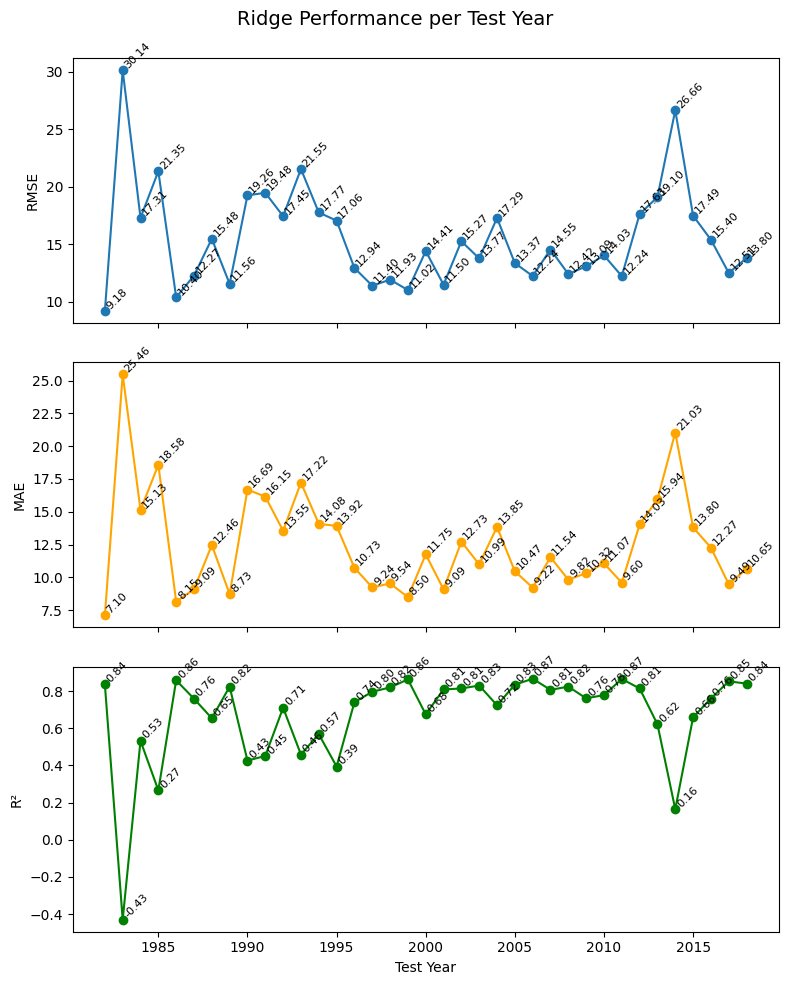

Running model: Lasso


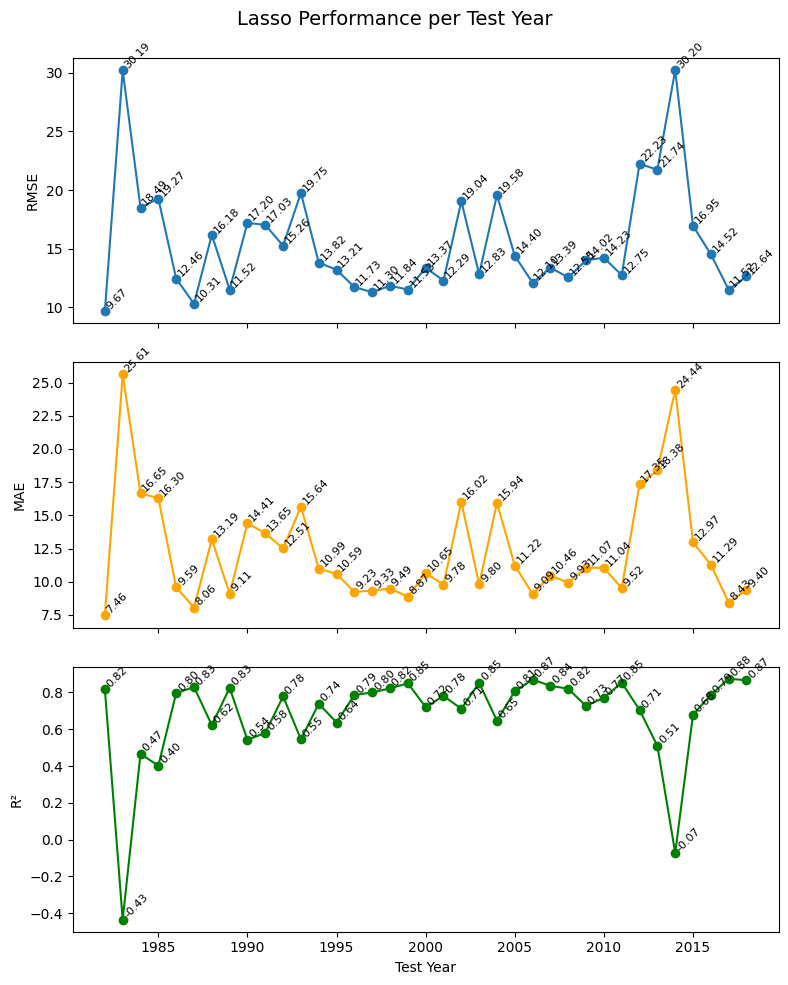

Running model: ElasticNet


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.390e+04, tolerance: 1.351e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.983e+04, tolerance: 2.874e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.030e+05, tolerance: 3.741e

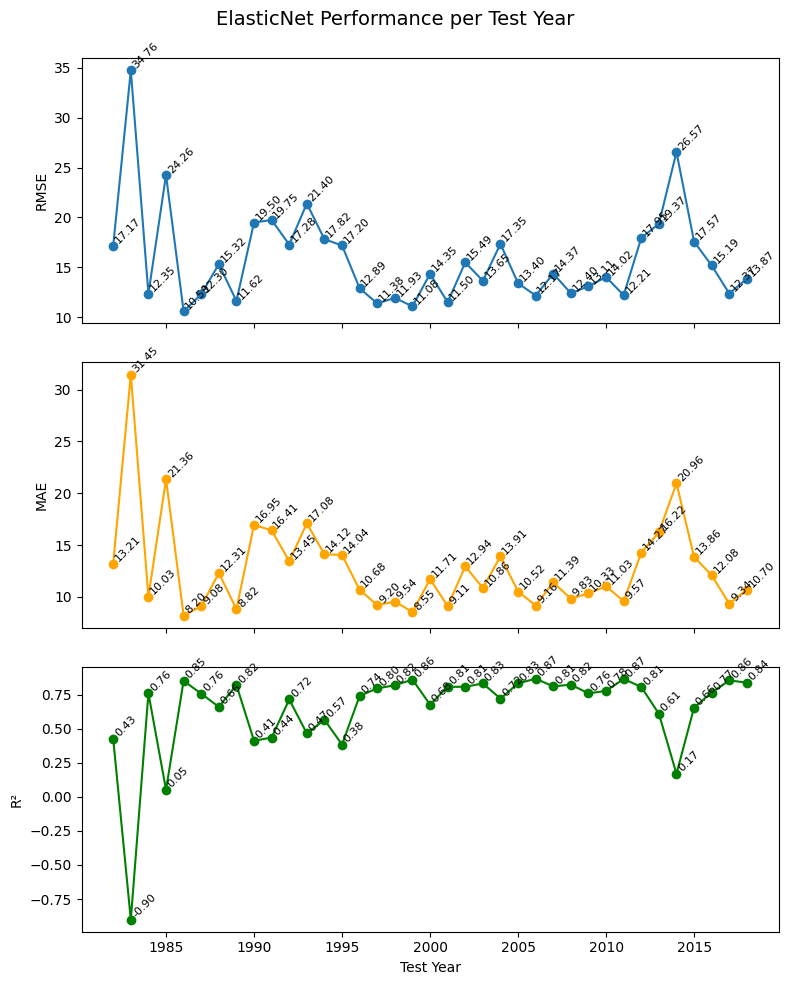

Running model: SVR


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

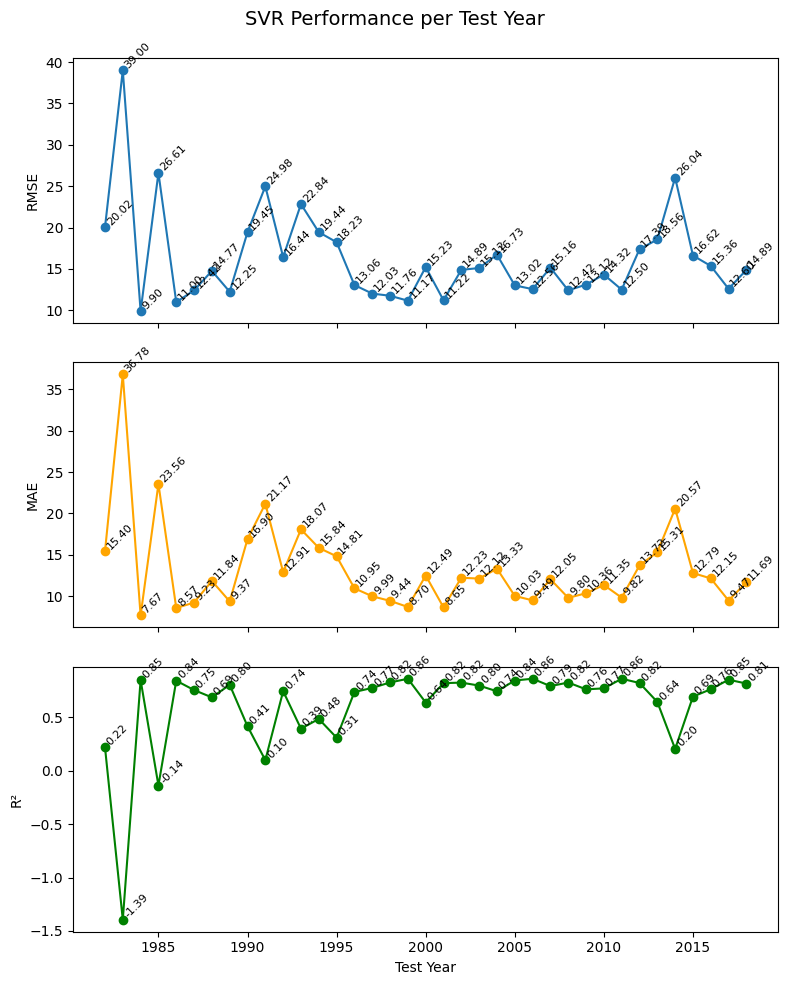


=== Leave-One-Year-Out CV Results ===
        Model       RMSE        MAE        R2
0       Ridge  16.176324  12.529812  0.817837
1       Lasso  16.145180  12.380713  0.818538
2  ElasticNet  16.659631  12.845254  0.806789
3         SVR  17.420142  13.331071  0.788747


In [ ]:
##Leave-one-year-out cv

models = {
    "Ridge": Ridge(alpha=100.0),
    "Lasso": Lasso(alpha=0.9),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5),
    "SVR": LinearSVR(
    C=10.0,
    epsilon=0.1,
    max_iter=5000,
    random_state=42)
}

results = []

non_model_cols = ['yield']

for name, model in models.items():
    print(f"Running model: {name}")

    y_true_all = []
    y_pred_all = []

    year_metrics = []

    for test_year in sorted(df["year"].unique()):
        if test_year == df["year"].min():
            continue

        # Train on all previous years
        train_data = df[df["year"] < test_year]
        test_data = df[df["year"] == test_year]

        X_train = train_data.drop(columns = non_model_cols)
        X_test = test_data.drop(columns = non_model_cols)
        y_train = train_data["yield"]
        y_test = test_data["yield"]

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Fit and predict
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        year_metrics.append({
        "Year": test_year,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2})

    metrics_df = pd.DataFrame(year_metrics)
    globals()[f"{name}_metrics_df"] = metrics_df

    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    axes[0].plot(metrics_df["Year"], metrics_df["RMSE"], marker='o')
    for x, rmse_val in zip(metrics_df["Year"], metrics_df["RMSE"]):
      axes[0].text(x, rmse_val, f"{rmse_val:.2f}", ha='left', va='bottom', fontsize=8, rotation=45)
    axes[0].set_ylabel("RMSE")

    axes[1].plot(metrics_df["Year"], metrics_df["MAE"], marker='o', color='orange')
    for x, mae_val in zip(metrics_df["Year"], metrics_df["MAE"]):
        axes[1].text(x, mae_val, f"{mae_val:.2f}", ha='left', va='bottom', fontsize=8, rotation=45)
    axes[1].set_ylabel("MAE")

    axes[2].plot(metrics_df["Year"], metrics_df["R2"], marker='o', color='green')
    for x, r2_val in zip(metrics_df["Year"], metrics_df["R2"]):
        axes[2].text(x, r2_val, f"{r2_val:.2f}", ha='left', va='bottom', fontsize=8, rotation=45)
    axes[2].set_ylabel("R²")
    axes[2].set_xlabel("Test Year")

    plt.suptitle(f"{name} Performance per Test Year", fontsize=14)
    plt.tight_layout()
    plt.show()

 # Compute metrics over all years
    rmse_all = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
    mae_all = mean_absolute_error(y_true_all, y_pred_all)
    r2_all = r2_score(y_true_all, y_pred_all)

    results.append({"Model": name, "RMSE": rmse_all, "MAE": mae_all, "R2": r2_all})

# ================================
# 7. Summarize results
# ================================
results_df = pd.DataFrame(results)
print("\n=== Leave-One-Year-Out CV Results ===")
print(results_df)

Running model: Ridge


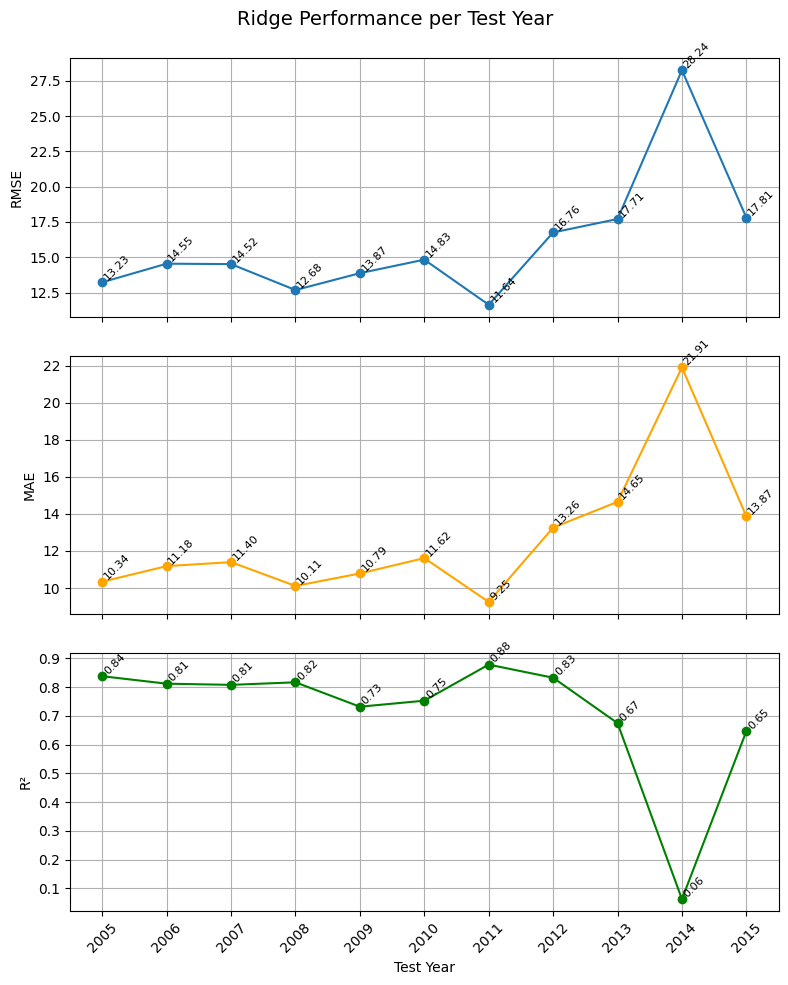

Running model: Lasso


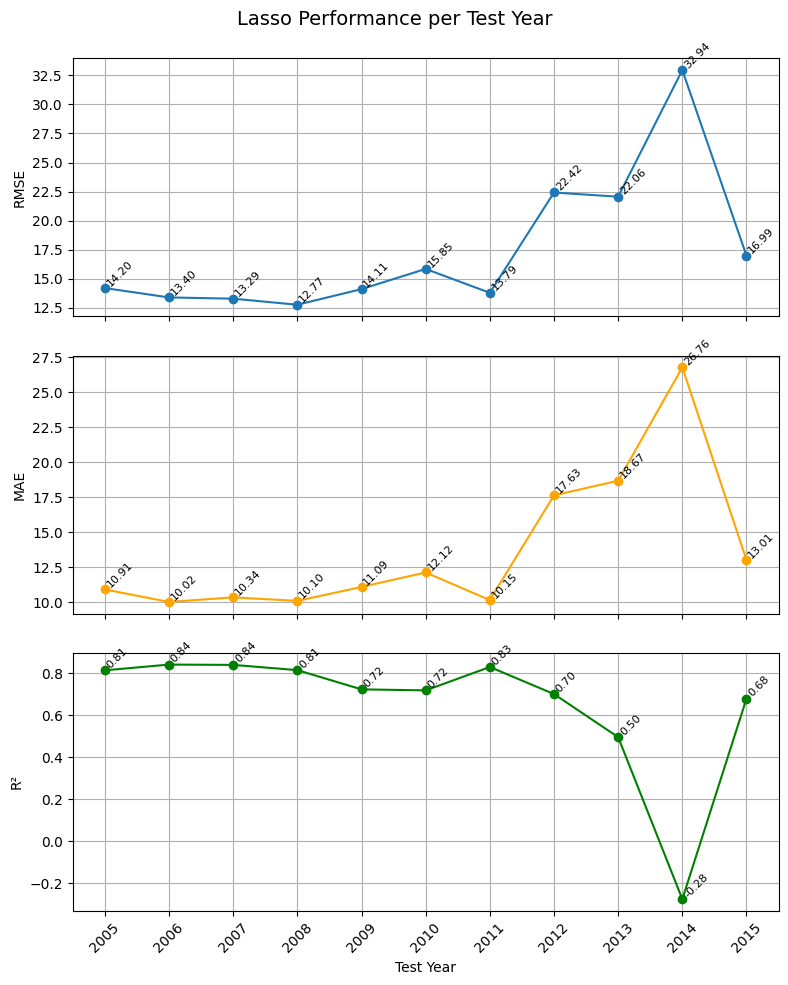

Running model: ElasticNet


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.699e+05, tolerance: 1.751e+03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.671e+05, tolerance: 1.808e+03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.864e+05, tolerance: 1.816e

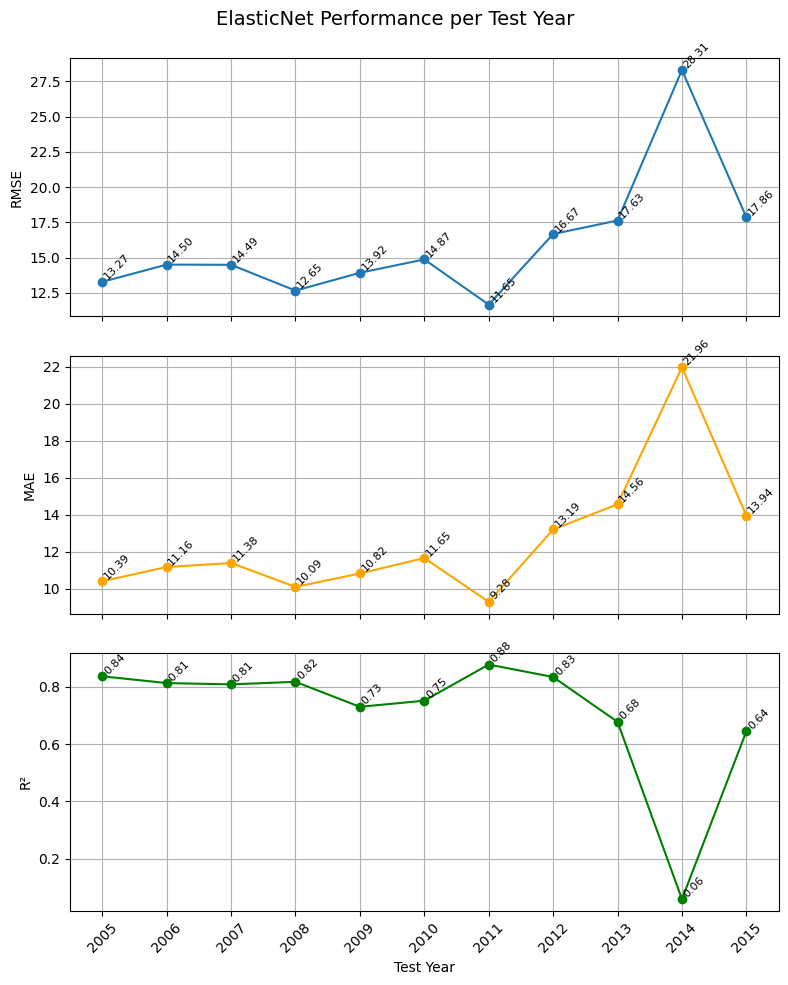

Running model: SVR


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

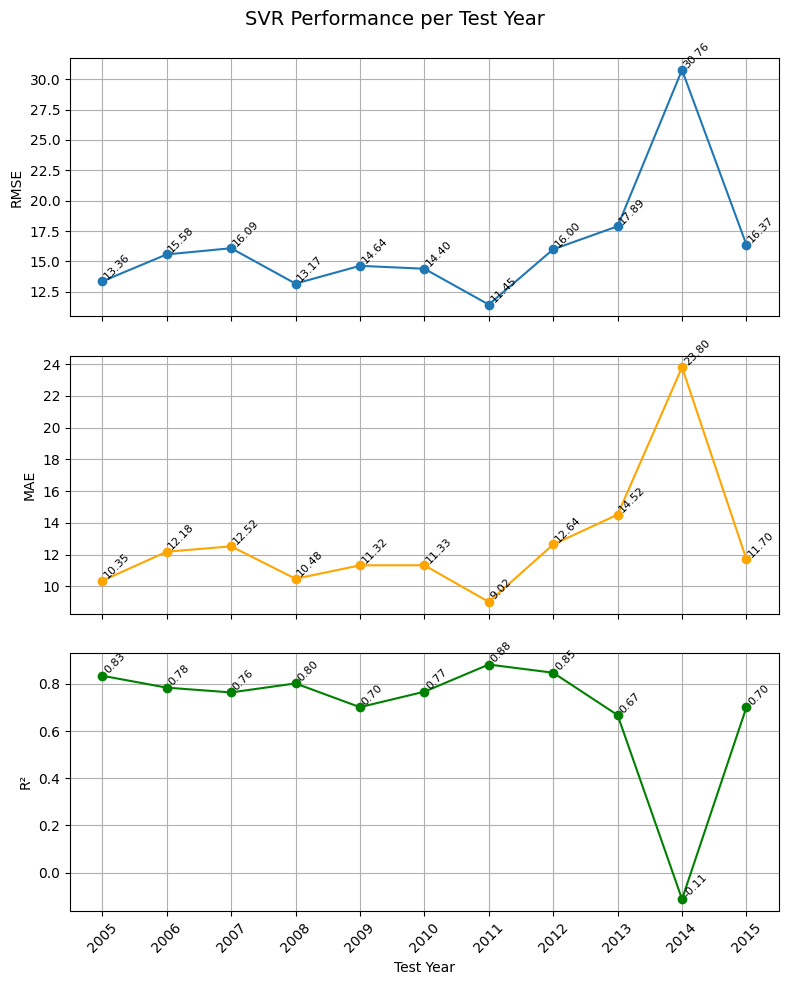


=== Leave-One-Year-Out CV Results ===
        Model       RMSE        MAE        R2
0       Ridge  16.439539  12.496626  0.784268
1       Lasso  18.254088  13.591113  0.734016
2  ElasticNet  16.440424  12.499547  0.784245
3         SVR  16.936073  12.650334  0.771039


In [ ]:
##Leave-one-year-out cv (2005-2015)

test_years = list(range(2005, 2016))

models = {
    "Ridge": Ridge(alpha=100.0),
    "Lasso": Lasso(alpha=0.9),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5),
    "SVR": LinearSVR(
    C=10.0,
    epsilon=0.1,
    max_iter=5000,
    random_state=42)
}

results = []

#years = df['year'].unique().tolist()

non_model_cols = ['yield']

for name, model in models.items():
    print(f"Running model: {name}")

    y_true_all = []
    y_pred_all = []

    year_metrics = []

    for test_year in test_years:
      train_start = test_year - 15
      train_end = test_year - 1

      # Train on 15 previous years
      train_data = df[(df["year"] >= train_start) & (df["year"] <= train_end)]
      test_data = df[df["year"] == test_year]

      X_train = train_data.drop(columns = non_model_cols)
      X_test = test_data.drop(columns = non_model_cols)
      y_train = train_data["yield"]
      y_test = test_data["yield"]

      # Scale features
      scaler = StandardScaler()
      X_train_scaled = scaler.fit_transform(X_train)
      X_test_scaled = scaler.transform(X_test)

      # Fit and predict
      model.fit(X_train_scaled, y_train)
      y_pred = model.predict(X_test_scaled)

      y_true_all.extend(y_test)
      y_pred_all.extend(y_pred)

      rmse = np.sqrt(mean_squared_error(y_test, y_pred))
      mae = mean_absolute_error(y_test, y_pred)
      r2 = r2_score(y_test, y_pred)

      year_metrics.append({
      "Year": test_year,
      "RMSE": rmse,
      "MAE": mae,
      "R2": r2})

    metrics_df = pd.DataFrame(year_metrics)
    globals()[f"{name}_metrics_df"] = metrics_df

    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    axes[0].plot(metrics_df["Year"], metrics_df["RMSE"], marker='o')
    for x, rmse_val in zip(metrics_df["Year"], metrics_df["RMSE"]):
      axes[0].text(x, rmse_val, f"{rmse_val:.2f}", ha='left', va='bottom', fontsize=8, rotation=45)
    axes[0].set_ylabel("RMSE")

    axes[1].plot(metrics_df["Year"], metrics_df["MAE"], marker='o', color='orange')
    for x, mae_val in zip(metrics_df["Year"], metrics_df["MAE"]):
        axes[1].text(x, mae_val, f"{mae_val:.2f}", ha='left', va='bottom', fontsize=8, rotation=45)
    axes[1].set_ylabel("MAE")

    axes[2].plot(metrics_df["Year"], metrics_df["R2"], marker='o', color='green')
    for x, r2_val in zip(metrics_df["Year"], metrics_df["R2"]):
        axes[2].text(x, r2_val, f"{r2_val:.2f}", ha='left', va='bottom', fontsize=8, rotation=45)
    axes[2].set_ylabel("R²")
    axes[2].set_xlabel("Test Year")

    for ax in axes:
      ax.set_xticks(test_years)
      ax.set_xticklabels(test_years, rotation=45)
      ax.grid(True)

    plt.suptitle(f"{name} Performance per Test Year", fontsize=14)
    plt.tight_layout()
    plt.show()

 # Compute metrics over all years
    rmse_all = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
    mae_all = mean_absolute_error(y_true_all, y_pred_all)
    r2_all = r2_score(y_true_all, y_pred_all)

    results.append({"Model": name, "RMSE": rmse_all, "MAE": mae_all, "R2": r2_all})

# ================================
# 7. Summarize results
# ================================
results_df = pd.DataFrame(results)
print("\n=== Leave-One-Year-Out CV Results ===")
print(results_df)